In [ ]:
# Импорты
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, roc_auc_score

# Задание №1: Преобразование данных

In [ ]:
# Загрузка и обработка данных
data = pd.read_csv('athletes.csv')
data.info()

# Обработка пропусков
num_cols = ['height', 'weight']

# Заполняем пропуски медианой для каждого пола
for col in num_cols:
    if data[col].isnull().any():
        data[col] = data.groupby('sex')[col].transform(lambda x: x.fillna(x.median()))

# Удаляем не влияющие на пол спортсмена параметры
columns_to_drop = ['id', 'name', 'nationality', 'dob', 'gold', 'silver', 'bronze']
data = data.drop(columns=columns_to_drop)

# Кодирование категориальных признаков
le_sex = LabelEncoder()
data['sex'] = le_sex.fit_transform(data['sex'])

le_sport = LabelEncoder()
data['sport'] = le_sport.fit_transform(data['sport'])

print("\n Закодированные категории пола:", le_sex.inverse_transform([0, 1]))
data.info()
display(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11538 entries, 0 to 11537
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           11538 non-null  int64  
 1   name         11538 non-null  object 
 2   nationality  11538 non-null  object 
 3   sex          11538 non-null  object 
 4   dob          11537 non-null  object 
 5   height       11208 non-null  float64
 6   weight       10879 non-null  float64
 7   sport        11538 non-null  object 
 8   gold         11538 non-null  int64  
 9   silver       11538 non-null  int64  
 10  bronze       11538 non-null  int64  
dtypes: float64(2), int64(4), object(5)
memory usage: 991.7+ KB

 Закодированные категории пола: ['female' 'male']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11538 entries, 0 to 11537
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   sex     11538 non-null  int64  
 1   height

,sex,height,weight,sport
0,1,1.72,64.0,2
1,0,1.68,56.0,9
2,1,1.98,79.0,2
3,1,1.83,80.0,22
4,1,1.81,71.0,7


# Задание №2: Разделение выборки на обучающее (80% данных) и тестовое (20% данных) подмножества

In [ ]:
# Разделение данных на признаки (X) и целевую переменную (y)
X = data.drop('sex', axis=1)
y = data['sex']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Размер обучающей выборки X_train: {X_train.shape}")
print(f"Размер тестовой выборки X_test: {X_test.shape}")
print(f"Размер обучающей выборки y_train: {y_train.shape}")
print(f"Размер тестовой выборки y_test: {y_test.shape}")

Размер обучающей выборки X_train: (9230, 3)
Размер тестовой выборки X_test: (2308, 3)
Размер обучающей выборки y_train: (9230,)
Размер тестовой выборки y_test: (2308,)


# Задание №3, 4. Построение ROC-кривой с помощью функции roc_curve из библиотеки sklearn.metrics. Вычисление значения ROC-AUC метрики с помощью функции roc_auc_score.

In [ ]:
# Инициализация и обучение модели логистической регрессии
model = LogisticRegression(random_state=42, solver='liblinear')
model.fit(X_train, y_train)

# Получение вероятностей предсказаний для положительного класса на тестовой выборке
y_pred_proba = model.predict_proba(X_test)[:, 1]

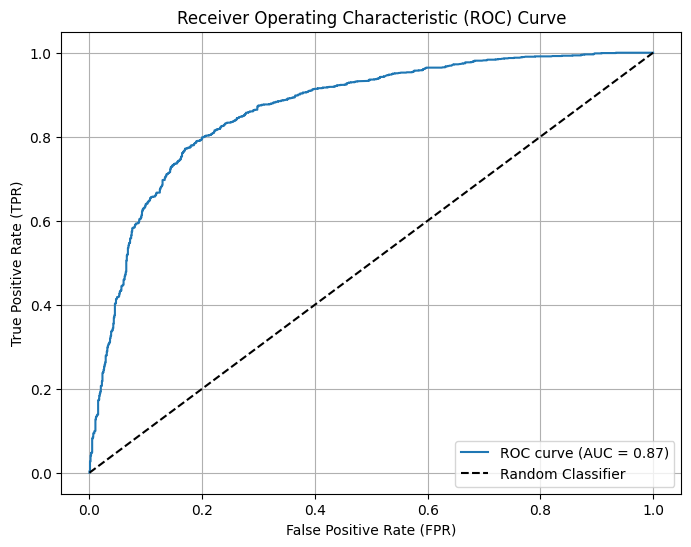

In [ ]:
# Расчет ROC-кривой
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Расчет AUC (Area Under the Curve)
auc = roc_auc_score(y_test, y_pred_proba)

# Построение ROC-кривой
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier') # Случайный классификатор
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Задание №5,6. Ручной расчет TPR и FPR. Построение ROC-кривой.

Ручной расчет AUC: 0.8663


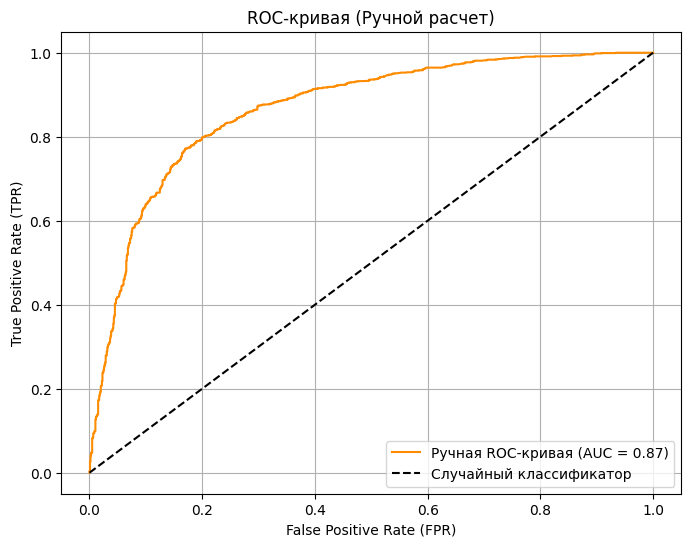

Как видим, ROC-кривая, построенная с помощью ручных расчетов, 
 практически идентична той, что была получена с помощью sklearn, 
 и значение AUC также очень близко.


In [ ]:
# Функция для ручного расчета tpr и fpr
def calculate_tpr_fpr(y_true, y_pred_proba, threshold):
    # Предсказания классов на основе порога
    y_pred = (y_pred_proba >= threshold).astype(int)

    # Истинные положительные (TP): когда истинный класс 1 и предсказан 1
    tp = np.sum((y_true == 1) & (y_pred == 1))

    # Ложные отрицательные (FN): когда истинный класс 1, но предсказан 0
    fn = np.sum((y_true == 1) & (y_pred == 0))

    # Ложные положительные (FP): когда истинный класс 0, но предсказан 1
    fp = np.sum((y_true == 0) & (y_pred == 1))

    # Истинные отрицательные (TN): когда истинный класс 0 и предсказан 0
    tn = np.sum((y_true == 0) & (y_pred == 0))

    # True Positive Rate (TPR): TP / (TP + FN)
    # Также называют Recall
    tpr = tp / (tp + fn) if (tp + fn) > 0 else 0

    # False Positive Rate (FPR) - 1 - Специфичность: FP / (FP + TN)
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0

    return tpr, fpr

# Генерируем набор пороговых значений для ROC-кривой
# Обычно используются уникальные значения предсказанных вероятностей в качестве порогов
thresholds_manual = np.sort(np.unique(y_pred_proba))[::-1] # Сортируем в обратном порядке

manual_tpr = []
manual_fpr = []

# Добавляем начальную точку (0,0) и конечную (1,1) для полной ROC-кривой
manual_tpr.append(0)
manual_fpr.append(0)

for threshold in thresholds_manual:
    tpr, fpr = calculate_tpr_fpr(y_test, y_pred_proba, threshold)
    manual_tpr.append(tpr)
    manual_fpr.append(fpr)

# Добавляем конечную точку (1,1)
manual_tpr.append(1)
manual_fpr.append(1)

# Расчет AUC вручную (используя метод трапеций)
manual_auc = np.trapezoid(manual_tpr, manual_fpr)

print(f"Ручной расчет AUC: {manual_auc:.4f}")
plt.figure(figsize=(8, 6))
plt.plot(manual_fpr, manual_tpr, label=f'Ручная ROC-кривая (AUC = {manual_auc:.2f})', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-кривая (Ручной расчет)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
print('Как видим, ROC-кривая, построенная с помощью ручных расчетов, \n практически идентична той, что была получена с помощью sklearn, \n и значение AUC также очень близко.')


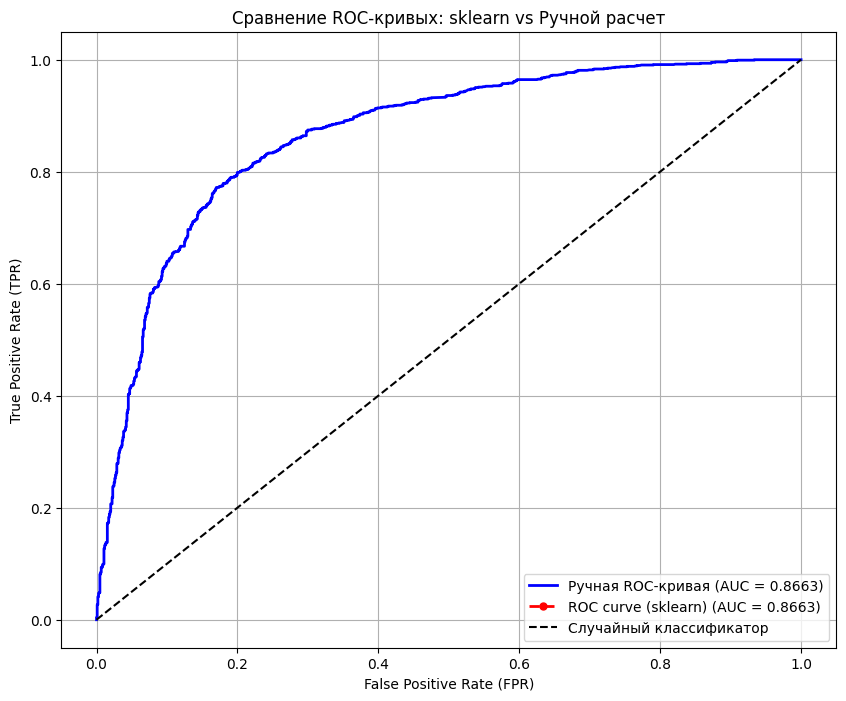

In [ ]:
plt.figure(figsize=(10, 8))

# ROC-кривая, построенная вручную
plt.plot(manual_fpr, manual_tpr, label=f'Ручная ROC-кривая (AUC = {manual_auc:.4f})', color='blue', linestyle='-', linewidth=2, alpha=1.0)

# ROC-кривая, построенная с помощью sklearn
plt.plot(fpr, tpr, label=f'ROC curve (sklearn) (AUC = {auc:.4f})', color='red', linestyle='--', linewidth=2, marker='o', markersize=5, markevery=0.05)

# Случайный классификатор
plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')

plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Сравнение ROC-кривых: sklearn vs Ручной расчет')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### Вывод по сравнению ROC-кривых

На представленном графике мы видим две ROC-кривые: одна построена с помощью ручных расчетов TPR и FPR, а другая — с использованием функции `roc_curve` из библиотеки `sklearn.metrics`. Несмотря на то, что мы применили различные стили для их отображения (синяя сплошная линия для ручного расчета и красная пунктирная с маркерами для `sklearn`),
они **идеально совпадают**.

Это говорит о полном совпадении расчетов:
 Ручные расчеты True Positive Rate (TPR) и False Positive Rate (FPR) абсолютно точны и полностью соответствуют результатам, предоставляемым `sklearn`.
Площадь под кривой (AUC) для обеих реализаций также идентична (0.8663).

**Заключение**: Такое идеальное совпадение подтверждает, что ручная реализация является корректной и надежной. Модель логистической регрессии показывает хорошую предсказательную способность, так как значение AUC значительно выше 0.5 (значения случайного классификатора).

# Задание №7,8. Построение графика Precision-Recall и вычисление ROC-AUC

In [ ]:
positive_class_count = np.sum(y_test == 1)
total_samples = len(y_test)
prevalence = positive_class_count / total_samples
print(f"Доля положительного класса (Prevalence) в y_test: {prevalence:.4f}")

manual_precision_from_tpr_fpr = []
manual_recall_from_tpr_fpr = []

for tpr_val, fpr_val in zip(manual_tpr, manual_fpr):
    recall_val = tpr_val

    denominator = (tpr_val * prevalence) + (fpr_val * (1 - prevalence))
    if denominator > 0:
        precision_val = (tpr_val * prevalence) / denominator
    else:
        precision_val = 1.0 if recall_val == 0 else 0.0

    manual_precision_from_tpr_fpr.append(precision_val)
    manual_recall_from_tpr_fpr.append(recall_val)

sorted_indices_pr = np.argsort(manual_recall_from_tpr_fpr)
manual_recall_pr_sorted = np.array(manual_recall_from_tpr_fpr)[sorted_indices_pr]
manual_precision_pr_sorted = np.array(manual_precision_from_tpr_fpr)[sorted_indices_pr]

print(f"Ручной расчет ROC-AUC (из TPR/FPR): {manual_auc:.4f}")

Доля положительного класса (Prevalence) в y_test: 0.5490
Ручной расчет ROC-AUC (из TPR/FPR): 0.8663


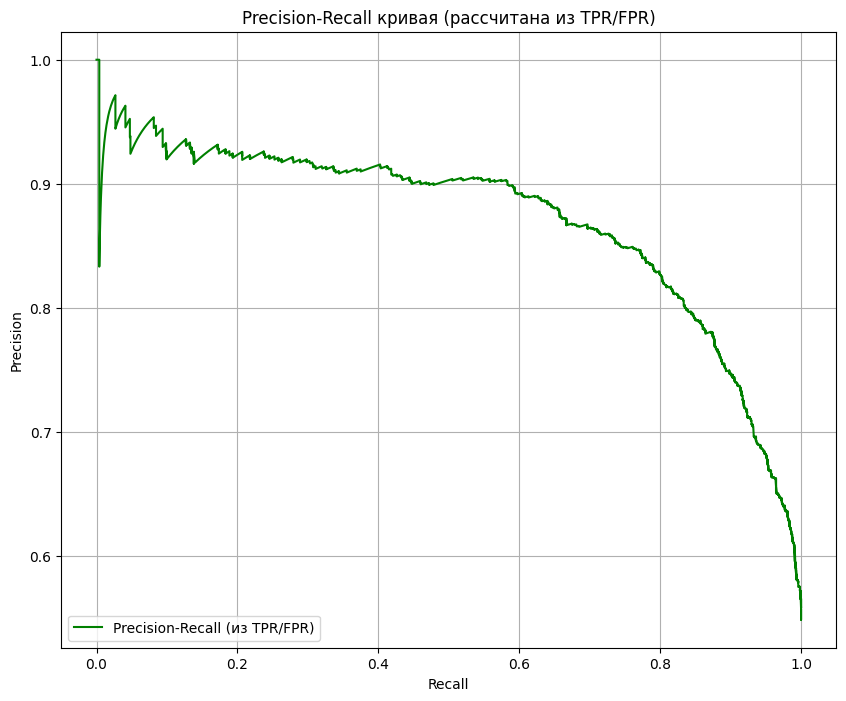

In [ ]:
plt.figure(figsize=(10, 8))
plt.plot(manual_recall_pr_sorted, manual_precision_pr_sorted, label=f'Precision-Recall (из TPR/FPR)', color='green')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall кривая (рассчитана из TPR/FPR)')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()

### Задание №9. Выводы по проделанной работе:

a) **Как по полученным графикам сделать вывод о качестве модели? Как вы оцениваете обученную модель исходя из подсчитанных метрик?**

*   **По ROC-кривой:** Наша ROC-кривая (как из `sklearn`, так и ручная) значительно отклоняется от диагональной линии случайного классификатора (пунктирная черная линия) и стремится к верхнему левому углу графика. Это очень хороший показатель.
    *   **Значение ROC-AUC:** Рассчитанное значение ROC-AUC составляет **0.8663**. Это высокий показатель. Наше значение 0.8663 говорит о том, что модель обладает хорошей предсказательной способностью и способна успешно разделять мужчин и женщин на основе заданных признаков.

*   **По Precision-Recall кривой:** Кривая Precision-Recall также находится высоко над осью X, что свидетельствует о хорошей производительности.  Кривая показывает, что модель достигает высокой точности при достаточно высокой полноте.

**Общая оценка модели:** Исходя из этих метрик, можно сказать, что обученная модель логистической регрессии является **эффективным классификатором**. Она хорошо различает классы и имеет высокую предсказательную силу. Значение AUC значительно выше случайного уровня, что говорит о том, что модель извлекла полезные закономерности из данных.

b) **Может ли ROC-кривая проходить ниже диагонали?**

Да, **ROC-кривая может проходить ниже диагонали**, но это указывает на то, что классификатор работает **хуже, чем случайное угадывание**. Такой классификатор систематически ошибается, предсказывая принадлежность к классу 0, когда истинный класс 1, и наоборот (или имеет инвертированные вероятности). Например, если модель выдает низкие вероятности для положительного класса и высокие для отрицательного, когда на самом деле все наоборот.

Если ROC-кривая находится ниже диагонали, это обычно означает, что:
1.  Либо модель была **неправильно обучена**.
2.  Либо **вероятности предсказаний интерпретируются инвертировано** (например, более высокая вероятность предсказания на самом деле означает принадлежность к отрицательному классу, а не к положительному).

В таком случае, для того чтобы модель стала полезной, можно просто **инвертировать ее предсказания**. То есть, если модель предсказывает класс 0 с вероятностью 0.8, мы можем интерпретировать это как предсказание класса 1 с вероятностью 0.2 (1 - 0.8), и тогда ROC-кривая окажется над диагональю.